# Overall Cross-Benchmark Leaderboards

This notebook builds version leaderboards aggregated across benchmarks from `baseline` and `v10+` results.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search). Overall scores for `baseline` aggregate only benchmarks that have a baseline run.

It supports:
- configurable **metric weights**
- configurable **benchmark weights** (default equal benchmark weighting)
- two ranking modes:
  - Primary metrics
  - Primary + Diversity

A separate **Overall primary leaderboard (with ablation studies)** section optionally includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/overall
_repo_root = Path.cwd().parents[2]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    build_overall_version_leaderboard,
    discover_benchmark_names,
    plot_leaderboard_scores,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)


In [2]:
# Configuration
benchmarks = discover_benchmark_names(base_path)
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

# Default benchmark weighting is equal.
# Customize this dict to emphasize/de-emphasize specific benchmarks.
benchmark_weights = {benchmark: 1.0 for benchmark in benchmarks}

print("Base path:", base_path)
print("Benchmarks discovered:", benchmarks)
print("Primary metric weights:", primary_metric_weights)
print("Primary + Diversity metric weights:", primary_plus_diversity_metric_weights)
print("Benchmark weights:", benchmark_weights)


Base path: /home/runner/work/sage-nrp-image-search/sage-nrp-image-search/benchmarking/benchmarks
Benchmarks discovered: ['Cloudbench', 'Commonobjectsbench', 'Firebench', 'INQUIRE', 'Sagebench']
Primary metric weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity metric weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}
Benchmark weights: {'Cloudbench': 1.0, 'Commonobjectsbench': 1.0, 'Firebench': 1.0, 'INQUIRE': 1.0, 'Sagebench': 1.0}


## Overall Primary Leaderboard

Composite score uses `MRR` and `Success@25`.


,system_version,benchmark_count,MRR,Success@25,composite_score,rank_overall
0,v13,5,0.506235,0.587177,0.546706,1
1,v10,5,0.473390,0.573181,0.523285,2
2,v11,5,0.431017,0.609053,0.520035,3
3,v15,5,0.485815,0.553614,0.519714,4
4,v14,5,0.474457,0.562625,0.518541,5
5,v12,5,0.376341,0.598770,0.487556,6
6,baseline,5,0.394192,0.511317,0.452754,7


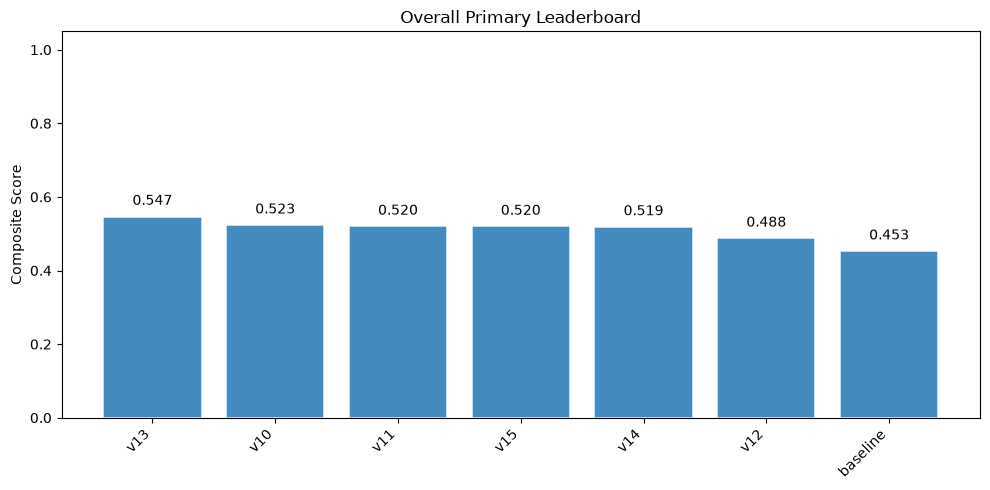

In [3]:
overall_primary_df = build_overall_version_leaderboard(
    base_path=base_path,
    benchmarks=benchmarks,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    benchmark_weights=benchmark_weights,
)

display(overall_primary_df)
plot_leaderboard_scores(overall_primary_df, label_column="system_version", title="Overall Primary Leaderboard")


## Overall Primary + Diversity Leaderboard

Composite score adds `Diversity@25`.


,system_version,benchmark_count,MRR,Success@25,Diversity@25,composite_score,rank_overall
0,v13,5,0.506235,0.587177,0.275926,0.456446,1
1,v15,5,0.485815,0.553614,0.285605,0.441678,2
2,v14,5,0.474457,0.562625,0.287290,0.441457,3
3,v10,5,0.473390,0.573181,0.244298,0.430290,4
4,v11,5,0.431017,0.609053,0.249047,0.429706,5
5,v12,5,0.376341,0.598770,0.247738,0.407617,6
6,baseline,5,0.394192,0.511317,0.163078,0.356196,7


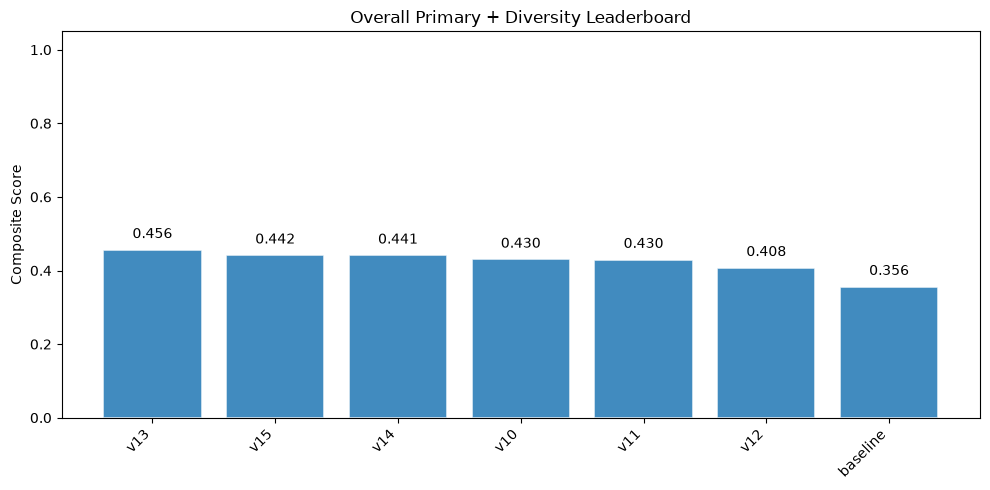

In [4]:
overall_primary_plus_diversity_df = build_overall_version_leaderboard(
    base_path=base_path,
    benchmarks=benchmarks,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    benchmark_weights=benchmark_weights,
)

display(overall_primary_plus_diversity_df)
plot_leaderboard_scores(
    overall_primary_plus_diversity_df,
    label_column="system_version",
    title="Overall Primary + Diversity Leaderboard",
)


## Overall Primary Leaderboard (with Ablation Studies)

Same weighted composite as the overall primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.


,system_version,benchmark_count,MRR,Success@25,composite_score,rank_overall
0,v13,5,0.506235,0.587177,0.546706,1
1,ablation_img_only,5,0.459436,0.617281,0.538358,2
2,v10,5,0.473390,0.573181,0.523285,3
3,v11,5,0.431017,0.609053,0.520035,4
4,v15,5,0.485815,0.553614,0.519714,5
5,v14,5,0.474457,0.562625,0.518541,6
6,ablation_vec_only,5,0.425646,0.603916,0.514781,7
7,ablation_cap_only,5,0.443006,0.555552,0.499279,8
8,v12,5,0.376341,0.598770,0.487556,9
9,baseline,5,0.394192,0.511317,0.452754,10


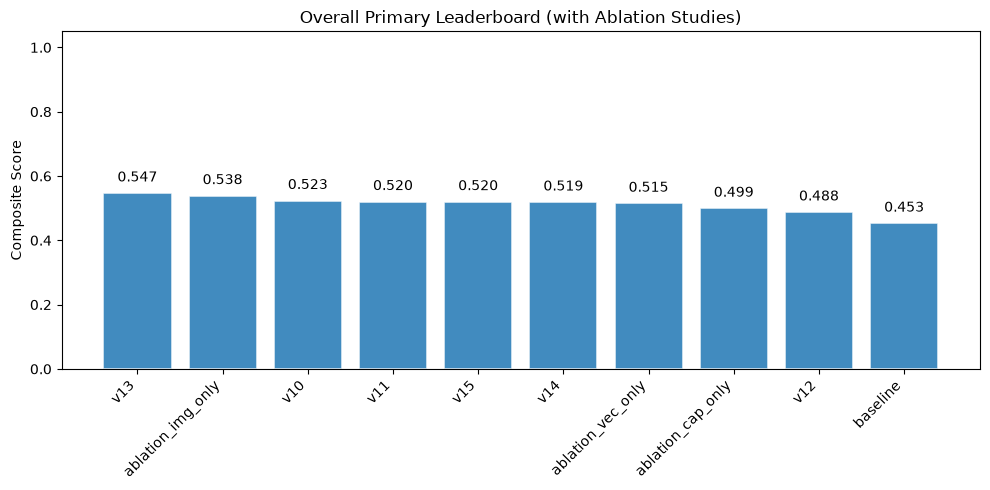

In [5]:
overall_primary_ablation_df = build_overall_version_leaderboard(
    base_path=base_path,
    benchmarks=benchmarks,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    benchmark_weights=benchmark_weights,
)

display(overall_primary_ablation_df)
plot_leaderboard_scores(
    overall_primary_ablation_df,
    label_column="system_version",
    title="Overall Primary Leaderboard (with Ablation Studies)",
)
